# 2. Depuración, ingeniería de características y partición

In [1]:
from config import *

crudo = pd.read_csv(
    DATOS_CRUDOS / "diabetic_data.csv",
    na_values=["?"],
    keep_default_na=False,
    low_memory=False,
)
print(f"Punto de partida: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas")

Punto de partida: 101,766 filas x 50 columnas


## 2.1. Construcción de la variable objetivo

In [2]:
distribucion = (
    crudo["readmitted"]
    .value_counts()
    .rename("Encuentros")
    .to_frame()
)

distribucion["Porcentaje (%)"] = (
    distribucion["Encuentros"]
    / distribucion["Encuentros"].sum()
    * 100
).round(2)

distribucion.index.name = "Categoría"

tabla(
    distribucion,
    filas=10,
    titulo="Distribución de la variable objetivo: readmitted"
)

### Distribución de la variable objetivo: readmitted

### Exclusión de altas incompatibles con una readmisión

Un paciente que fallece durante la hospitalización o que es trasladado a cuidados paliativos no puede reingresar. Conservar esos registros introduce ruido irreducible: quedan etiquetados como "no readmitido" por una razón ajena al mecanismo clínico que se quiere modelar.

In [3]:
DESTINOS_EXCLUIDOS = [11, 13, 14, 19, 20, 21]

excluidos = crudo["discharge_disposition_id"].isin(DESTINOS_EXCLUIDOS)

comparacion = pd.DataFrame(
    {
        "Encuentros": [
            excluidos.sum(),
            (~excluidos).sum()
        ],
        "Porcentaje del total (%)": [
            100 * excluidos.mean(),
            100 * (~excluidos).mean()
        ],
        "Tasa de readmisión <30 días (%)": [
            100 * (
                crudo.loc[excluidos, "readmitted"] == "<30"
            ).mean(),
            100 * (
                crudo.loc[~excluidos, "readmitted"] == "<30"
            ).mean()
        ]
    },
    index=[
        "Destinos excluidos",
        "Resto de destinos"
    ]
).round(2)

comparacion.index.name = "Grupo"

tabla(
    comparacion,
    filas=10,
    titulo="Comparación de encuentros según destino al alta"
)

### Comparación de encuentros según destino al alta

In [4]:
ETIQUETAS_EXCLUIDOS = {
    11: "Fallecido",
    13: "Hospicio / domicilio",
    14: "Hospicio / institución",
    19: "Fallecido en domicilio (hospicio)",
    20: "Fallecido en institución (hospicio)",
    21: "Fallecido, lugar desconocido (hospicio)",
}

desglose = (
    crudo.loc[excluidos]
    .groupby("discharge_disposition_id")["readmitted"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["<30", ">30", "NO"], fill_value=0)
)

desglose["Total de encuentros"] = desglose.sum(axis=1)

desglose["Readmisión <30 días (%)"] = (
    100 * desglose["<30"] / desglose["Total de encuentros"]
).round(2)

desglose = desglose.rename(
    columns={
        "<30": "Readmisión <30 días",
        ">30": "Readmisión >30 días",
        "NO": "Sin readmisión"
    }
)

desglose.index = [
    ETIQUETAS_EXCLUIDOS.get(i, f"Código {i}")
    for i in desglose.index
]

desglose.index.name = "Destino al alta"

desglose = desglose.sort_values(
    "Readmisión <30 días (%)",
    ascending=False
)

tabla(
    desglose,
    filas=10,
    titulo="Desglose de destinos asociados con fallecimiento u hospicio"
)

### Desglose de destinos asociados con fallecimiento u hospicio

Los encuentros con alta por fallecimiento u hospicio son el 2.38 % del total y presentan una tasa de readmisión temprana del 1.77 %, frente al 11.39 % del resto. El desglose por código separa dos situaciones distintas. Entre los 1,652 encuentros con alta por fallecimiento no hay ni un solo caso de readmisión, como exige la lógica: el evento es imposible. Los 43 casos que componen ese 1.77 % residual provienen en su totalidad de los 771 encuentros con alta a cuidados paliativos, donde un reingreso sí es posible por una crisis de dolor o una complicación aguda. La razón para excluirlos no es entonces la imposibilidad del evento, sino la población objetivo: son pacientes en un régimen de atención orientado al confort y no a evitar el reingreso, de modo que la intervención que este modelo pretende orientar no les es aplicable.

## 2.2. Aplicación de los filtros con trazabilidad

In [5]:
traza = []


def registrar(etapa, datos, filas_anteriores=None, pacientes_anteriores=None):
    """
    Registra el estado del dataset en cada etapa del proceso de depuración.
    """

    filas_actuales = len(datos)
    pacientes_actuales = datos["patient_nbr"].nunique()

    registro = {
        "Etapa": etapa,
        "Filas": filas_actuales,
        "Columnas": datos.shape[1],
        "Pacientes": pacientes_actuales,
    }

    if filas_anteriores is not None:
        registro["Filas eliminadas"] = filas_anteriores - filas_actuales
        registro["Conservación (%)"] = round(
            100 * filas_actuales / filas_anteriores, 2
        )

    if pacientes_anteriores is not None:
        registro["Pacientes eliminados"] = (
            pacientes_anteriores - pacientes_actuales
        )

    traza.append(registro)


# Dataset inicial
limpio = crudo.copy()

registrar("0. Dataset crudo", limpio)

# --- Filtro 1: altas incompatibles con una readmisión --------------------
filas_previas = len(limpio)
pacientes_previos = limpio["patient_nbr"].nunique()

limpio = limpio[
    ~limpio["discharge_disposition_id"].isin(DESTINOS_EXCLUIDOS)
]

registrar(
    "1. Sin fallecimiento ni hospicio",
    limpio,
    filas_anteriores=filas_previas,
    pacientes_anteriores=pacientes_previos
)

# --- Filtro 2: género inválido -------------------------------------------
filas_previas = len(limpio)
pacientes_previos = limpio["patient_nbr"].nunique()

limpio = limpio[
    limpio["gender"] != "Unknown/Invalid"
]

registrar(
    "2. Sin género inválido",
    limpio,
    filas_anteriores=filas_previas,
    pacientes_anteriores=pacientes_previos
)


# Convertir el registro en DataFrame
trazabilidad = pd.DataFrame(traza)

trazabilidad.index.name = "N.º"

tabla(
    trazabilidad,
    filas=10,
    titulo="Trazabilidad del proceso de depuración"
)

### Trazabilidad del proceso de depuración

## 2.3. Elección de la unidad de análisis

In [6]:
IDENTIFICADOR = "patient_nbr"

# Las cohortes se construyen desde el crudo, aplicando solo las exclusiones
# clínicas, para poder comparar antes de decidir la unidad de análisis.
base = crudo[~crudo["discharge_disposition_id"].isin(DESTINOS_EXCLUIDOS)]
base = base[base["gender"] != "Unknown/Invalid"]
ordenado = base.sort_values("encounter_id")

cohortes = {
    "Todos los encuentros": base,
    "Uno aleatorio por paciente": (base.sample(frac=1, random_state=RANDOM_STATE)
                                       .drop_duplicates(IDENTIFICADOR)),
    "Primer encuentro por paciente": ordenado.drop_duplicates(IDENTIFICADOR,
                                                              keep="first"),
    "Último encuentro por paciente": ordenado.drop_duplicates(IDENTIFICADOR,
                                                              keep="last"),
}

comparacion_cohortes = pd.DataFrame({
    "registros": {k: len(v) for k, v in cohortes.items()},
    "pacientes": {k: v[IDENTIFICADOR].nunique() for k, v in cohortes.items()},
    "tasa positiva (%)": {k: 100 * (v["readmitted"] == "<30").mean()
                          for k, v in cohortes.items()},
}).round(2)
comparacion_cohortes

,registros,pacientes,tasa positiva (%)
Todos los encuentros,99340,69987,11.39
Uno aleatorio por paciente,69987,69987,7.44
Primer encuentro por paciente,69987,69987,8.98
Último encuentro por paciente,69987,69987,4.96


In [7]:
frecuencia = base[IDENTIFICADOR].value_counts()
primero = ordenado.drop_duplicates(IDENTIFICADOR, keep="first")
ultimo = ordenado.drop_duplicates(IDENTIFICADOR, keep="last")

varios_primero = primero[IDENTIFICADOR].map(frecuencia) > 1
varios_ultimo = ultimo[IDENTIFICADOR].map(frecuencia) > 1

sesgo_seleccion = pd.DataFrame({
    "pacientes": [
        (~varios_primero).sum(),
        varios_primero.sum(),
        varios_ultimo.sum(),
    ],
    "tasa positiva (%)": [
        100 * (primero.loc[~varios_primero, "readmitted"] == "<30").mean(),
        100 * (primero.loc[varios_primero, "readmitted"] == "<30").mean(),
        100 * (ultimo.loc[varios_ultimo, "readmitted"] == "<30").mean(),
    ],
}, index=["Un solo encuentro",
          "Primer encuentro de pacientes con varios",
          "Último encuentro de pacientes con varios"]).round(2)
sesgo_seleccion["% de la cohorte"] = (
    100 * sesgo_seleccion["pacientes"] / base[IDENTIFICADOR].nunique()
).round(1)
sesgo_seleccion

,pacientes,tasa positiva (%),% de la cohorte
Un solo encuentro,53646,4.26,76.7
Primer encuentro de pacientes con varios,16341,24.47,23.3
Último encuentro de pacientes con varios,16341,7.23,23.3


El capítulo 1 mostró que los encuentros de un mismo paciente no son independientes y que la posición del encuentro en el historial predice el desenlace. Hay cuatro formas de responder a ese problema y la elección afecta los resultados de forma sustancial, así que se documenta con evidencia.

| Estrategia | Registros | Tasa positiva | Problema |
|---|---|---|---|
| **Todos los encuentros (adoptada)** | 99,340 | 11.39 % | Requiere agrupar la validación por paciente |
| Un encuentro aleatorio por paciente | 69,987 | 7.44 % | Descarta el 30 % de los episodios |
| Primer encuentro por paciente | 69,987 | 8.98 % | Condiciona sobre la existencia de un episodio posterior |
| Último encuentro por paciente | 69,987 | 4.96 % | Censura a la derecha |

Que la misma cohorte produzca tasas entre el 4.96 % y el 11.39 % según el episodio que se elija no es variabilidad de muestreo: es sesgo de selección. El desglose lo hace explícito.

| Grupo | Pacientes | Tasa positiva |
|---|---|---|
| Pacientes con un solo encuentro (76.7 %) | 53646 | 4.26 % |
| Primer encuentro de pacientes con varios (23.3 %) | 16341 | 24.47 % |
| Último encuentro de pacientes con varios (23.3 %) | 16341 | 7.23 % |

Seleccionar el primer encuentro de un paciente con varios **condiciona sobre el futuro**: por construcción ese paciente volvió al hospital, y lo único que decide la etiqueta es si volvió antes o después de los 30 días. De ahí el 24.47 %, casi seis veces la tasa de los pacientes con un solo episodio. La cohorte resultante mezcla entonces dos subpoblaciones cuya diferencia es un artefacto del muestreo y no riesgo clínico. Simétricamente, quedarse con el último encuentro censura a la derecha: los reingresos posteriores al cierre de la ventana de observación en 2008 no se registran y esos casos se etiquetan como no readmitidos.

Se adoptan por tanto **todos los encuentros**, con `StratifiedGroupKFold` agrupado por `patient_nbr` en cada partición y en cada fold de la validación cruzada. Las razones:

1. **No introduce sesgo de selección.** Ningún episodio se descarta y ninguna etiqueta depende de información posterior al alta que se está evaluando.
2. **La prevalencia es la correcta.** El 11.39 % es la tasa de readmisión a 30 días por episodio, que es exactamente la cantidad que los sistemas de salud miden y penalizan. Una tasa por paciente respondería a una pregunta distinta.
3. **La unidad de análisis coincide con la unidad de decisión.** El modelo se aplicaría en el momento de un alta concreta, no a un paciente en abstracto.
4. **El agrupamiento resuelve la dependencia sin coste añadido.** `StratifiedGroupKFold` mantiene a cada paciente íntegramente dentro de un mismo fold, de modo que el modelo nunca se evalúa sobre un paciente que ya vio en entrenamiento. Su costo computacional es idéntico al de `StratifiedKFold`; el incremento es únicamente el 42 % de filas adicionales.

Se descarta la alternativa de colapsar el historial en una fila por paciente con variables agregadas. Tiene tres impedimentos en este dataset: la variable objetivo perdería su definición por episodio, cualquier agregado calculado sobre todos los episodios incorporaría información posterior al evento a predecir, y el 76.7 % de los pacientes tiene un único encuentro, por lo que esas variables serían constantes para tres de cada cuatro filas. Además, el dataset no incluye fechas, así que los intervalos entre ingresos no son calculables. Las variables `number_outpatient`, `number_emergency` y `number_inpatient` ya recogen esa información agregada del año previo a cada episodio, mirando solo hacia atrás y con una ventana idéntica para todas las filas, que es justo lo que un agregado construido a mano no podría garantizar.

### 2.3.1. Ponderación implícita de los pacientes recurrentes

Conservar todos los encuentros tiene una consecuencia que conviene declarar: **cada paciente pesa en la función de pérdida en proporción a su número de episodios**. Un paciente con cuarenta ingresos contribuye cuarenta veces más al ajuste que uno con un solo ingreso, de modo que el modelo optimiza preferentemente el acierto sobre el perfil del paciente crónico recurrente.

Esto no es un defecto del diseño, sino su consecuencia lógica. La unidad de decisión es el alta, no el paciente: cada egreso obliga a decidir si ese paciente necesita seguimiento reforzado, y un paciente que egresa cuarenta veces genera cuarenta decisiones. Ponderar por episodios es entonces la representación fiel del problema que el modelo va a resolver en la práctica, mientras que dar a cada paciente el mismo peso respondería a una pregunta distinta, la de caracterizar individuos en lugar de orientar altas.

El precio de esa elección es que el desempeño observado refleja sobre todo a los pacientes de mayor recurrencia. Conviene tenerlo presente al interpretar los resultados de los capítulos 7 a 9: una métrica agregada no garantiza el mismo desempeño en un paciente que ingresa por primera vez, cuya tasa de readmisión es sustancialmente menor.

### 2.3.2. Por qué la posición del encuentro no se incorpora como predictor

El capítulo 1 mostró que la posición del encuentro en el historial del paciente se asocia con fuerza al desenlace: la tasa de readmisión pasa del 8.80 % en el primer episodio registrado al 26.42 % a partir del quinto. Esa evidencia se usó para justificar el agrupamiento de la validación por paciente, pero la variable **no se incorpora al conjunto de predictores**, por tres razones.

La primera es de definición. La posición no mide el historial clínico del paciente, sino su historial *dentro de esta muestra*: 130 instituciones, diez años de registro y solo los episodios que cumplieron los criterios de inclusión del dataset. Un paciente con veinte hospitalizaciones previas en otra red recibiría el valor cero.

La segunda es el truncamiento por la izquierda. Un paciente cuyo primer ingreso ocurrió antes de 1999 aparece con posición cero en su primer episodio registrado, aunque no fuera realmente el primero. El valor cero resulta entonces ambiguo: agrupa a los pacientes sin historial previo con aquellos cuyo historial cae fuera de la ventana de observación, y el modelo no puede distinguirlos.

La tercera es la redundancia con una variable mejor definida. `number_inpatient` mide las hospitalizaciones del paciente en el año previo a cada episodio, con una ventana fija e idéntica para todas las filas e independiente de dónde comience el registro. Captura el mismo concepto clínico —historial de hospitalización— sin la ambigüedad anterior, y el capítulo 4 confirma que es el predictor numérico con mayor tamaño de efecto del conjunto.

## 2.4. Eliminación de columnas y variable objetivo

### 2.4.1. Columnas descartadas

Las eliminaciones responden a motivos distintos y cada una se justifica por separado.

**`readmitted`.** Es la variable original de tres niveles, que se deriva en la celda de aplicación de esta sección. Conservarla dejaría el desenlace entre los predictores, la forma más directa de fuga de información posible: cualquier modelo alcanzaría un AUC perfecto sin haber aprendido nada. Se elimina después de derivar `readmitted_30`, no antes.

**`encounter_id`.** Identificador secuencial del episodio, sin contenido clínico. Su eliminación no solo evita ruido: al ser creciente en el tiempo, un modelo podría usarlo para captar tendencias del propio registro (cambios de codificación, incorporación de hospitales a la red) en lugar del mecanismo clínico que se quiere modelar.

**`weight`.** El 96.86 % de los valores está ausente. Imputar supondría generar un valor sintético para casi toda la muestra, de modo que la variable aportaría el artefacto de la imputación y no información del paciente. La sección 4.3 del capítulo 1 añade un argumento definitivo: su ausencia es la única del conjunto completamente independiente del desenlace (chi² nulo, p = 1.00), así que tampoco el hecho de faltar es informativo. Se descarta sin sustituto.

**`payer_code`.** El 39.56 % de valores ausentes y, sobre todo, su naturaleza: identifica al asegurador, no describe el estado clínico del paciente. Su asociación con la readmisión reflejaría diferencias de cobertura y acceso al sistema antes que riesgo médico, lo que introduciría un factor de confusión difícil de interpretar en un modelo destinado a orientar decisiones clínicas al alta. Se deja constancia en las limitaciones de que el contexto asegurador queda, por tanto, fuera del análisis.

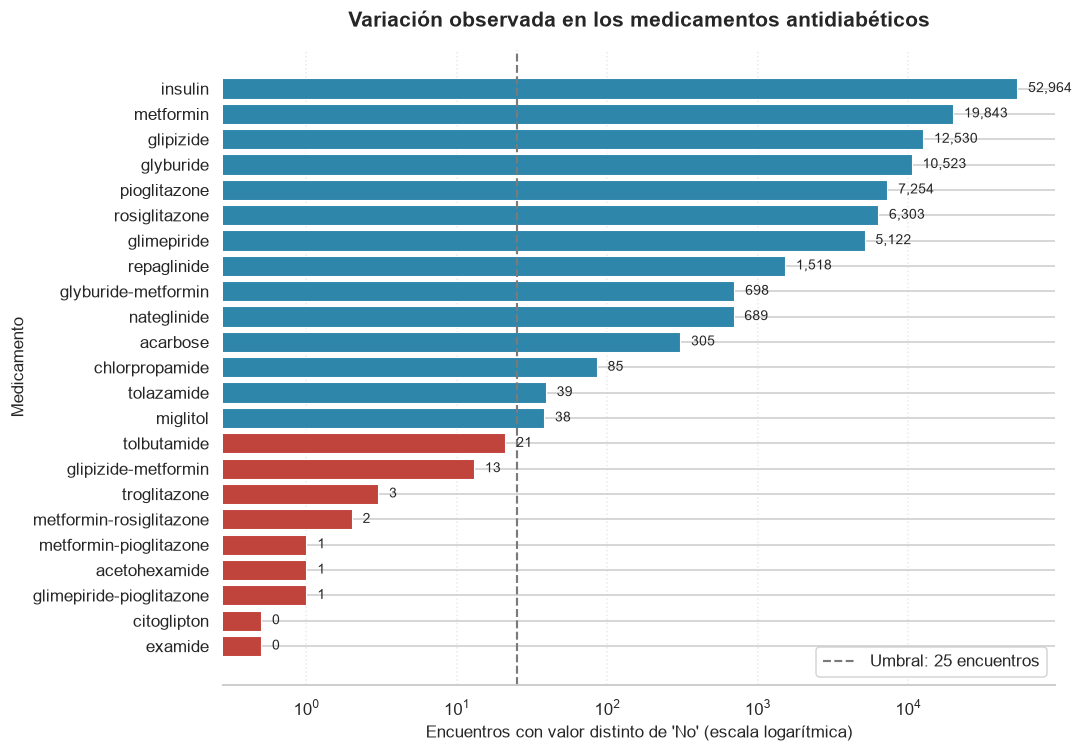

RESUMEN DE DEPURACIÓN DEL PANEL FARMACOLÓGICO

Medicamentos descartados (9):
 • acetohexamide
 • citoglipton
 • examide
 • glimepiride-pioglitazone
 • glipizide-metformin
 • metformin-pioglitazone
 • metformin-rosiglitazone
 • tolbutamide
 • troglitazone

Medicamentos retenidos: 14


In [8]:
PANEL_FARMACOS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide",
    "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone",
    "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone",
]

MINIMO_VARIACION = 25

# Número de encuentros en los que cada fármaco presenta un valor distinto de "No"
variacion = (
    pd.Series({
        farmaco: int((limpio[farmaco] != "No").sum())
        for farmaco in PANEL_FARMACOS
    })
    .sort_values()
)

# Colores según el umbral establecido
colores = [
    PALETA[1] if valor < MINIMO_VARIACION else PALETA[0]
    for valor in variacion
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    variacion.index,
    variacion.clip(lower=0.5),
    color=colores,
    edgecolor="white",
    linewidth=0.7
)

# Escala logarítmica para visualizar fármacos con frecuencias muy diferentes
ax.set_xscale("log")

# Línea de referencia
ax.axvline(
    MINIMO_VARIACION,
    color=GRIS,
    linestyle="--",
    linewidth=1.4,
    label=f"Umbral: {MINIMO_VARIACION} encuentros"
)

# Etiquetas de frecuencia
for posicion, valor in enumerate(variacion):
    ax.text(
        max(valor, 0.5) * 1.18,
        posicion,
        f"{valor:,}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Variación observada en los medicamentos antidiabéticos",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Encuentros con valor distinto de 'No' "
    "(escala logarítmica)",
    fontsize=11
)

ax.set_ylabel("Medicamento", fontsize=11)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

ax.legend(
    loc="lower right",
    frameon=True
)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


FARMACOS_DESCARTADOS = sorted(
    variacion[variacion < MINIMO_VARIACION].index
)

FARMACOS = [
    farmaco
    for farmaco in PANEL_FARMACOS
    if farmaco not in FARMACOS_DESCARTADOS
]

print("RESUMEN DE DEPURACIÓN DEL PANEL FARMACOLÓGICO")

print(
    f"\nMedicamentos descartados ({len(FARMACOS_DESCARTADOS)}):"
)

if FARMACOS_DESCARTADOS:
    print(" • " + "\n • ".join(FARMACOS_DESCARTADOS))
else:
    print("Ninguno")

print(f"\nMedicamentos retenidos: {len(FARMACOS)}")


In [9]:
resumen_variacion = (
    variacion
    .rename("Encuentros con variación")
    .to_frame()
)

resumen_variacion["Porcentaje del total (%)"] = (
    100
    * resumen_variacion["Encuentros con variación"]
    / len(limpio)
).round(3)

resumen_variacion["Decisión"] = np.where(
    resumen_variacion["Encuentros con variación"] < MINIMO_VARIACION,
    "Descartado",
    "Retenido"
)

resumen_variacion["Umbral aplicado"] = MINIMO_VARIACION

resumen_variacion.index.name = "Medicamento"

resumen_variacion = (
    resumen_variacion
    .sort_values(
        by=["Decisión", "Encuentros con variación"],
        ascending=[True, True]
    )
)

tabla(
    resumen_variacion,
    filas=25,
    titulo="Resumen de variación y decisión sobre medicamentos"
)

### Resumen de variación y decisión sobre medicamentos

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

categoricas_actuales = [c for c in columnas_texto(limpio) if c != "readmitted"]
objetivo = (limpio["readmitted"] == "<30").astype(int)
CASI_NULOS = [f for f in FARMACOS_DESCARTADOS
              if (limpio[f] != "No").sum() < 5]
ESCASOS = [f for f in FARMACOS_DESCARTADOS if f not in CASI_NULOS]

escenarios = {
    f"Solo sin varianza casi nula (descarta {len(CASI_NULOS)})":
        [c for c in categoricas_actuales if c not in CASI_NULOS],
    f"Umbral de {MINIMO_VARIACION} (descarta {len(FARMACOS_DESCARTADOS)})":
        [c for c in categoricas_actuales if c not in FARMACOS_DESCARTADOS],
    "Panel completo (descarta 0)": categoricas_actuales,
}

filas = []
for etiqueta, columnas in escenarios.items():
    matriz = OneHotEncoder(handle_unknown="infrequent_if_exist",
                           min_frequency=0.01).fit_transform(limpio[columnas])
    modelo = LogisticRegression(solver="saga", max_iter=200,
                                random_state=RANDOM_STATE)
    inicio = time.perf_counter()
    modelo.fit(matriz, objetivo)
    duracion = time.perf_counter() - inicio
    no_nulos = np.asarray((matriz != 0).sum(axis=0)).ravel()
    filas.append({
        "escenario": etiqueta,
        "columnas": matriz.shape[1],
        "columnas con menos de 5 no nulos": int((no_nulos < 5).sum()),
        "columnas con menos de 30 no nulos": int((no_nulos < 30).sum()),
        "tiempo (s)": duracion,
    })

pd.DataFrame(filas).set_index("escenario").round(2)

,columnas,columnas con menos de 5 no nulos,columnas con menos de 30 no nulos,tiempo (s)
escenario,,,,
Solo sin varianza casi nula (descarta 7),166,0,2,6.70
Umbral de 25 (descarta 9),162,0,0,5.47
Panel completo (descarta 0),178,5,7,15.68


**Los nueve fármacos con variación insuficiente.** El criterio de eliminación no puede ser la concentración relativa: `repaglinide` tiene el 98.5 % de sus registros en `No` y aun así 1,518 encuentros con variación, suficientes para estimar un efecto. Tampoco puede basarse en el número de readmisiones dentro de la categoría minoritaria, porque eso supondría usar la variable objetivo para seleccionar predictores, una forma de selección supervisada ejecutada fuera de la validación cruzada.

Se adopta un criterio no supervisado y de naturaleza computacional: se descartan los fármacos con **menos de veinticinco encuentros de variación**. `examide` y `citoglipton` no registran ninguno; `acetohexamide`, `glimepiride-pioglitazone` y `metformin-pioglitazone` registran uno; `metformin-rosiglitazone` dos; `troglitazone` tres; `glipizide-metformin` trece y `tolbutamide` veintiuno. El siguiente fármaco del panel salta a treinta y ocho, de modo que el umbral cae en un tramo vacío de la distribución y no parte ningún grupo por la mitad.

La justificación del umbral no es teórica sino el resultado de un diagnóstico, y la comparación de tres escenarios lo sustenta. El costo del solver no depende del número de columnas sino de su dispersión: conservar el panel completo añade un 10 % de columnas respecto al conjunto depurado, pero **cuadruplica** el tiempo de ajuste de la regresión logística. Conservar solo los dos fármacos con trece y veintiún encuentros añade un 2.5 % de columnas y aun así eleva el tiempo en torno a dos tercios. El número de columnas con menos de treinta valores no nulos predice el tiempo mucho mejor que el total de columnas, y el umbral de veinticinco encuentros es exactamente el punto en que esas columnas desaparecen.

El mecanismo es el condicionamiento del problema de optimización. Una columna con un puñado de valores no nulos sobre casi cien mil filas introduce una dirección de curvatura casi nula, lo que aumenta el número de condición de la matriz de diseño y ralentiza cada iteración del solver SAGA sin aportar capacidad predictiva. Extrapolado a las dieciséis corridas de la familia lineal, con 185 ajustes cada una, la diferencia entre el escenario depurado y el panel completo supone varias horas de cómputo adicional. En Naive Bayes el problema es distinto pero del mismo origen: una columna de varianza nula vuelve numéricamente inestable la verosimilitud con los valores más pequeños de `var_smoothing`.

Los fármacos poco frecuentes que superan el umbral se conservan, y el capítulo 4 cuantifica la incertidumbre de su estimación en lugar de descartarlos: la escasez de una categoría no implica ausencia de señal, sino imposibilidad de estimarla con precisión, y ambas cosas se distinguen mirando el intervalo de confianza y no la tasa puntual.

In [11]:
# --- Variable objetivo ---------------------------------------------------
limpio["readmitted_30"] = (
    limpio["readmitted"] == "<30"
).astype(int)

# --- Columnas descartadas (justificación en la sección 2.4.1) -----------
COLUMNAS_DESCARTADAS = [
    "encounter_id",
    "weight",
    "payer_code",
    "readmitted"
]

limpio = limpio.drop(
    columns=COLUMNAS_DESCARTADAS + FARMACOS_DESCARTADOS
)

registrar(
    "3. Columnas descartadas y target derivado",
    limpio
)

# --- Visualización de la trazabilidad -----------------------------------
trazabilidad_final = pd.DataFrame(traza)

trazabilidad_final.index.name = "N.º"

tabla(
    trazabilidad_final,
    filas=10,
    titulo="Trazabilidad del proceso de depuración"
)

### Trazabilidad del proceso de depuración

La depuración lleva el conjunto de 101,766 a 99,340 encuentros, correspondientes a 69,987 pacientes, y de 50 a 38 columnas. Solo se descartan 2,426 registros, todos por las exclusiones clínicas de la sección 2.1: ningún encuentro se pierde por repetición de paciente.

## 2.5. Ingeniería de características

Todas las variables derivadas se construyen con información disponible **en el momento del alta**, condición necesaria para que el modelo sea aplicable en la práctica clínica.

### 2.5.1. Agrupación de los diagnósticos ICD-9

Cada encuentro registra hasta tres diagnósticos codificados en la novena revisión de la Clasificación Internacional de Enfermedades.

In [12]:
# Análisis de las variables diagnósticas
DIAGNOSTICOS = ["diag_1", "diag_2", "diag_3"]

estructura_diag = pd.DataFrame({
    "Códigos distintos": limpio[DIAGNOSTICOS].nunique(),

    "Valores faltantes": limpio[DIAGNOSTICOS].isna().sum(),

    "Faltantes (%)": (
        100 * limpio[DIAGNOSTICOS].isna().mean()
    ).round(3),

    "Código más frecuente (%)": (
        100
        * limpio[DIAGNOSTICOS].apply(
            lambda serie: serie.value_counts(normalize=True).iloc[0]
        )
    ).round(2),

    "Códigos con menos de 50 encuentros": [
        int((limpio[columna].value_counts() < 50).sum())
        for columna in DIAGNOSTICOS
    ]
})

estructura_diag.index.name = "Variable diagnóstica"

total_codigos = int(
    estructura_diag["Códigos distintos"].sum()
)

print(
    f"\nColumnas que generaría el one-hot sin agrupar: "
    f"{total_codigos:,}"
)
print("=" * 75)

tabla(
    estructura_diag,
    filas=10,
    titulo="Estructura y cardinalidad de las variables diagnósticas"
)


Columnas que generaría el one-hot sin agrupar: 2,248


### Estructura y cardinalidad de las variables diagnósticas

C:\Users\USER\AppData\Local\Temp\ipykernel_16848\3587658700.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


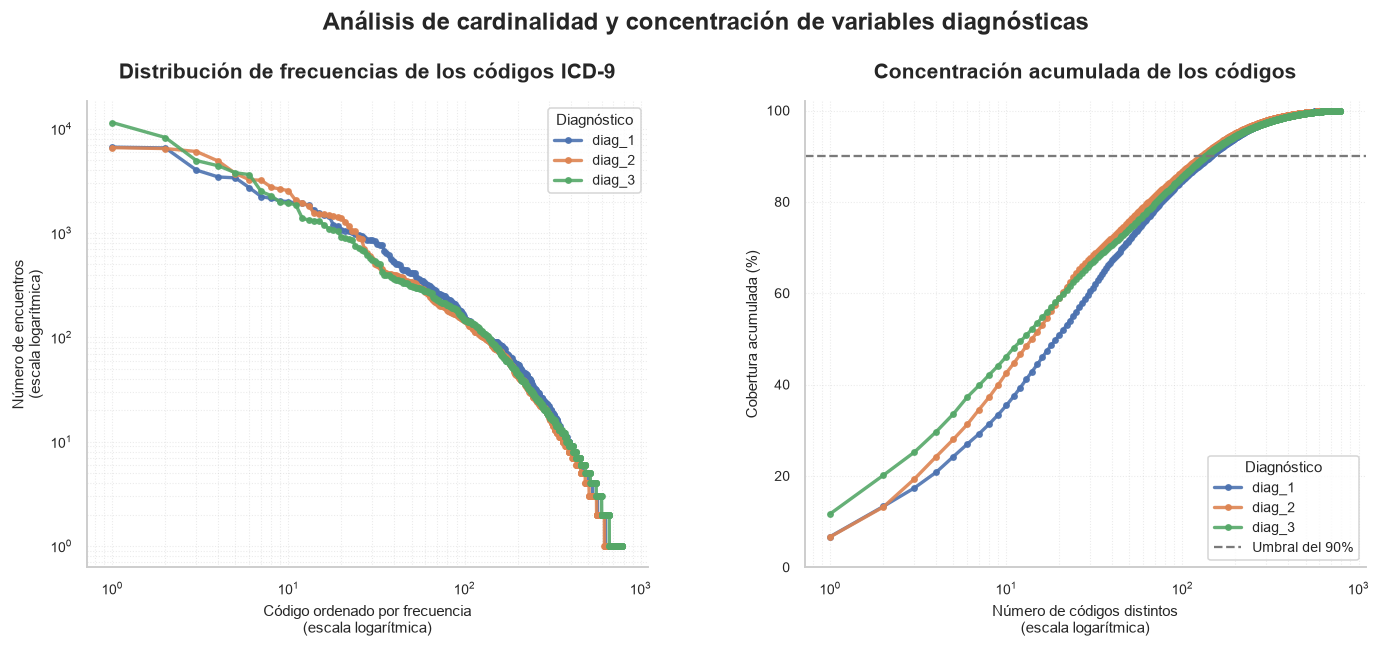

In [13]:
# Distribución y concentración de códigos ICD-9

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    gridspec_kw={"wspace": 0.28}
)

for columna in DIAGNOSTICOS:

    frecuencias = limpio[columna].value_counts()

    posiciones = range(1, len(frecuencias) + 1)

    axes[0].plot(
        posiciones,
        frecuencias.to_numpy(),
        label=columna,
        linewidth=2.2,
        marker="o",
        markersize=3.5,
        alpha=0.9
    )

    acumulado = (
        100 * frecuencias.cumsum() / frecuencias.sum()
    )

    axes[1].plot(
        posiciones,
        acumulado,
        label=columna,
        linewidth=2.2,
        marker="o",
        markersize=3.5,
        alpha=0.9
    )

# Gráfico 1: frecuencias

axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[0].set_title(
    "Distribución de frecuencias de los códigos ICD-9",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel(
    "Código ordenado por frecuencia\n(escala logarítmica)",
    fontsize=10
)

axes[0].set_ylabel(
    "Número de encuentros\n(escala logarítmica)",
    fontsize=10
)

axes[0].grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.7,
    alpha=0.4
)

axes[0].legend(
    title="Diagnóstico",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Gráfico 2: cobertura acumulada 

axes[1].axhline(
    90,
    linestyle="--",
    color=GRIS,
    linewidth=1.5,
    label="Umbral del 90%"
)

axes[1].set_xscale("log")
axes[1].set_ylim(0, 102)

axes[1].set_title(
    "Concentración acumulada de los códigos",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel(
    "Número de códigos distintos\n(escala logarítmica)",
    fontsize=10
)

axes[1].set_ylabel(
    "Cobertura acumulada (%)",
    fontsize=10
)

axes[1].grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.7,
    alpha=0.4
)

axes[1].legend(
    title="Diagnóstico",
    frameon=True,
    fontsize=9,
    title_fontsize=10
)


for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

fig.suptitle(
    "Análisis de cardinalidad y concentración de variables diagnósticas",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [14]:
# Significado clínico de los diagnósticos más frecuentes

SIGNIFICADO = {
    "428": "Insuficiencia cardíaca",
    "414": "Cardiopatía isquémica crónica",
    "786": "Síntomas respiratorios y torácicos",
    "410": "Infarto agudo de miocardio",
    "486": "Neumonía",
    "427": "Arritmias cardíacas",
    "491": "Bronquitis crónica",
    "715": "Osteoartrosis",
    "682": "Celulitis",
    "434": "Oclusión de arterias cerebrales",
    "996": "Complicaciones de cuidados médicos",
    "038": "Septicemia",
    "599": "Trastornos de las vías urinarias",
    "403": "Enfermedad renal hipertensiva",
    "780": "Síntomas generales",
    "276": "Trastornos de líquidos y electrolitos",
    "401": "Hipertensión esencial",
    "496": "Obstrucción crónica de las vías respiratorias",
    "411": "Cardiopatía isquémica aguda y subaguda",
    "272": "Trastornos del metabolismo de los lípidos",
    "585": "Enfermedad renal crónica",
    "518": "Otras enfermedades pulmonares",
    "435": "Isquemia cerebral transitoria",
    "440": "Aterosclerosis",
    "998": "Complicaciones de procedimientos",
}

# Generación de tablas por posición diagnóstica

POSICIONES_DIAGNOSTICAS = {
    "diag_1": "Principal",
    "diag_2": "Secundario",
    "diag_3": "Terciario",
}

for columna, posicion in POSICIONES_DIAGNOSTICAS.items():

    tabla_pos = (
        limpio[columna]
        .value_counts()
        .head(10)
        .rename("Encuentros")
        .to_frame()
    )

    tabla_pos["Porcentaje (%)"] = (
        100 * tabla_pos["Encuentros"] / len(limpio)
    ).round(2)

    tabla_pos["Significado clínico"] = [
        (
            "Diabetes mellitus"
            if str(codigo).startswith("250")
            else SIGNIFICADO.get(str(codigo), "Sin descripción")
        )
        for codigo in tabla_pos.index
    ]

    tabla_pos.index.name = "Código ICD-9"

    tabla(
        tabla_pos,
        filas=10,
        titulo=(
            f"Diez diagnósticos más frecuentes — "
            f"Posición {posicion.lower()}"
        )
    )

### Diez diagnósticos más frecuentes — Posición principal

### Diez diagnósticos más frecuentes — Posición secundario

### Diez diagnósticos más frecuentes — Posición terciario

In [15]:
# Los diecisiete capítulos del ICD-9, definidos por rangos contiguos. Se
# declaran como tabla y no como cadena de condicionales para que la
# taxonomía sea auditable y no dependa del orden de las comparaciones.
# --- Agrupación de diagnósticos según capítulos ICD-9 --------------------

CAPITULOS_ICD9 = [
    ("Infecciosas", 1, 139),
    ("Neoplasias", 140, 239),
    ("Endocrinas y metabólicas", 240, 279),
    ("Sangre", 280, 289),
    ("Mentales", 290, 319),
    ("Nervioso y sentidos", 320, 389),
    ("Circulatorio", 390, 459),
    ("Respiratorio", 460, 519),
    ("Digestivo", 520, 579),
    ("Genitourinario", 580, 629),
    ("Embarazo y parto", 630, 679),
    ("Piel", 680, 709),
    ("Musculoesquelético", 710, 739),
    ("Congénitas", 740, 759),
    ("Perinatales", 760, 779),
    ("Síntomas mal definidos", 780, 799),
    ("Lesiones y envenenamientos", 800, 999),
]


def agrupar_icd9(codigo):
    """
    Asigna cada código ICD-9 a su capítulo correspondiente.

    La diabetes mellitus (250.xx) recibe una categoría independiente,
    aunque pertenece al capítulo de enfermedades endocrinas y metabólicas.
    Los códigos V y E se agrupan como suplementarios.
    """

    if pd.isna(codigo) or codigo == "":
        return "No registrado"

    codigo = str(codigo).strip().upper()

    if codigo.startswith(("V", "E")):
        return "Suplementarios V y E"

    if codigo.startswith("250"):
        return "Diabetes"

    try:
        valor = float(codigo)
    except ValueError:
        return "No registrado"

    for nombre, inicio, fin in CAPITULOS_ICD9:
        if inicio <= valor <= fin:
            return nombre

    return "No registrado"



DIAGNOSTICOS = ["diag_1", "diag_2", "diag_3"]

POSICIONES_DIAGNOSTICAS = {
    "diag_1": "Principal",
    "diag_2": "Secundario",
    "diag_3": "Terciario"
}

codigos_distintos = {
    columna: limpio[columna].nunique()
    for columna in DIAGNOSTICOS
}

for columna in DIAGNOSTICOS:
    limpio[f"{columna}_grupo"] = (
        limpio[columna]
        .map(agrupar_icd9)
    )


limpio = limpio.drop(columns=DIAGNOSTICOS)


grupos_diag = pd.DataFrame({
    POSICIONES_DIAGNOSTICAS[columna]: (
        limpio[f"{columna}_grupo"]
        .value_counts(normalize=True)
        .mul(100)
    )
    for columna in DIAGNOSTICOS
}).fillna(0).round(2)

grupos_diag.index.name = "Grupo diagnóstico"

# Ordenar según la frecuencia del diagnóstico principal
grupos_diag = grupos_diag.sort_values(
    by="Principal",
    ascending=False
)


resumen_agrupacion = pd.DataFrame({
    "Indicador": [
        "Códigos distintos en diagnóstico principal",
        "Códigos distintos en diagnóstico secundario",
        "Códigos distintos en diagnóstico terciario",
        "Grupos diagnósticos después de agrupar",
        "Columnas ICD-9 originales eliminadas"
    ],
    "Resultado": [
        codigos_distintos["diag_1"],
        codigos_distintos["diag_2"],
        codigos_distintos["diag_3"],
        len(grupos_diag),
        len(DIAGNOSTICOS)
    ]
})

tabla(
    resumen_agrupacion,
    filas=10,
    titulo="Resumen de la agrupación de códigos ICD-9"
)

tabla(
    grupos_diag,
    filas=25,
    titulo="Distribución porcentual de los grupos diagnósticos"
)

### Resumen de la agrupación de códigos ICD-9

### Distribución porcentual de los grupos diagnósticos

El agrupamiento reduce entre 715 y 786 códigos distintos por columna a diecinueve categorías, con una cobertura del 100 % y sin ninguna selección manual: cada código cae en un capítulo por su rango numérico.

La comparación entre las tres posiciones diagnósticas caracteriza a la población. El aparato circulatorio domina en las tres por igual, alrededor del 30 %, lo que confirma que la comorbilidad cardiovascular es transversal en esta cohorte. La diabetes, en cambio, muestra un gradiente claro: aparece como diagnóstico principal en el 8.72 % de los encuentros, como secundario en el 12.79 % y como terciario en el 17.09 %. Es la confirmación cuantitativa de que en esta población la diabetes es mayoritariamente comorbilidad de fondo y no motivo de ingreso.

El gradiente inverso lo presentan los capítulos que sí motivan la hospitalización: el digestivo baja del 9.13 % al 3.53 % y las lesiones del 6.90 % al 1.91 %. Son causas agudas de ingreso, no condiciones crónicas acompañantes.

Las enfermedades endocrinas y metabólicas distintas de la diabetes siguen el patrón contrario, del 2.66 % al 8.95 %, coherente con el perfil metabólico del paciente diabético de larga evolución: dislipidemias y trastornos de líquidos y electrolitos que acompañan al ingreso sin causarlo.

Los capítulos poco frecuentes se agruparán con el umbral uniforme de la sección 2.6: dos categorías en el diagnóstico principal, dos en el secundario y una en el terciario. No se aplica aquí ningún criterio específico para los diagnósticos, sino el que ya rige para el resto de variables categóricas, de modo que no haya una regla distinta por bloque de variables.

### 2.5.2. Edad como variable ordinal

La edad viene agrupada en diez intervalos de amplitud constante. Al tener orden natural se codifica como entero, lo que evita generar diez columnas binarias y permite a los modelos lineales aprovechar la monotonía. La versión textual se descarta para no mantener dos representaciones de la misma información, que serían redundantes entre sí.

La codificación ordinal impone, además del orden, **distancias iguales** entre intervalos consecutivos: para un modelo lineal, pasar de `[20-30)` a `[30-40)` tiene el mismo efecto sobre la predicción que pasar de `[70-80)` a `[80-90)`. Este supuesto es más fuerte que el anterior y aquí la evidencia es mixta. La tasa de readmisión por grupo etario no es monótona: alcanza un máximo en el intervalo `[20-30)`, desciende hasta un mínimo en `[50-60)` y vuelve a crecer de forma moderada hacia los intervalos más avanzados. Los intervalos por debajo de los 30 años concentran una fracción pequeña de los encuentros, de modo que el supuesto de distancias iguales es una aproximación razonable para la gran mayoría de la muestra, pero no una descripción fiel de toda la escala.

Los modelos basados en árboles no se ven afectados por este supuesto: al dividir por umbrales, aprovechan únicamente el orden y no las distancias entre categorías. El supuesto solo compromete a la regresión logística y al SVM lineal, y en ambos casos su efecto es simplificar una relación que, en los extremos jóvenes de la escala, no es lineal ni monótona. Se declara como limitación explícita del preprocesamiento y no como un supuesto verificado.

In [16]:
# --- Transformación de la variable edad ----------------------------------

ORDEN_EDAD = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

ETIQUETAS_EDAD = {
    i: intervalo
    for i, intervalo in enumerate(ORDEN_EDAD)
}

# Crear una representación ordinal de la edad
MAPEO_EDAD = {
    intervalo: i
    for i, intervalo in enumerate(ORDEN_EDAD)
}

limpio["age_ord"] = limpio["age"].map(MAPEO_EDAD)

# Validar que todos los intervalos originales fueron transformados
sin_mapear = limpio.loc[
    limpio["age_ord"].isna(),
    "age"
].unique()

assert len(sin_mapear) == 0, (
    f"Intervalos de edad sin mapear: {sin_mapear}"
)

# Conservar una copia de la distribución original para documentar el cambio
distribucion_original_edad = (
    limpio["age"]
    .value_counts()
    .reindex(ORDEN_EDAD, fill_value=0)
    .rename("Encuentros")
    .to_frame()
)

distribucion_original_edad["Porcentaje (%)"] = (
    100
    * distribucion_original_edad["Encuentros"]
    / len(limpio)
).round(2)

distribucion_original_edad.index.name = "Intervalo de edad"

# Eliminar la variable categórica original
limpio = limpio.drop(columns=["age"])

# --- Distribución de la nueva variable ordinal ---------------------------

distribucion_edad = (
    limpio["age_ord"]
    .value_counts()
    .sort_index()
    .rename(index=ETIQUETAS_EDAD)
    .rename("Encuentros")
    .to_frame()
)

distribucion_edad["Porcentaje (%)"] = (
    100
    * distribucion_edad["Encuentros"]
    / len(limpio)
).round(2)

distribucion_edad.index.name = "Intervalo de edad"

# --- Resumen de la transformación ----------------------------------------

resumen_edad = pd.DataFrame({
    "Indicador": [
        "Variable original",
        "Nueva variable",
        "Tipo de transformación",
        "Cantidad de categorías",
        "Variable original eliminada"
    ],
    "Resultado": [
        "age",
        "age_ord",
        "Codificación ordinal de intervalos",
        len(ORDEN_EDAD),
        "Sí"
    ]
})

tabla(
    distribucion_edad,
    filas=10,
    titulo="Distribución de la variable edad transformada"
)

### Distribución de la variable edad transformada

### 2.5.3. Historial de utilización de servicios

Se añade un indicador binario de hospitalización previa, que en la literatura clínica es uno de los predictores más robustos de reingreso.

In [17]:

UTILIZACION = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

limpio["hospitalizacion_previa"] = (
    limpio["number_inpatient"] > 0
).astype(int)

utilizacion = pd.DataFrame({
    "% con valor cero": (
        100 * (limpio[UTILIZACION] == 0).mean()
    ),
    "Media": limpio[UTILIZACION].mean(),
    "Mediana": limpio[UTILIZACION].median(),
    "Percentil 95": limpio[UTILIZACION].quantile(0.95),
    "Máximo": limpio[UTILIZACION].max()
}).round(2)

utilizacion.index = [
    "Consultas ambulatorias",
    "Atenciones de emergencia",
    "Hospitalizaciones"
]

utilizacion.index.name = "Tipo de utilización"

porcentaje_hospitalizacion = (
    100 * limpio["hospitalizacion_previa"].mean()
)

print(
    f"Encuentros con hospitalización previa registrada: "
    f"{porcentaje_hospitalizacion:.2f} %"
)

tabla(
    utilizacion,
    filas=10,
    titulo="Estadísticas descriptivas de la utilización hospitalaria"
)

Encuentros con hospitalización previa registrada: 33.32 %


### Estadísticas descriptivas de la utilización hospitalaria

Las tres variables presentan exceso de ceros, aunque en grados distintos: entre el 83 % y el 89 % de los encuentros no registran consultas externas ni visitas a urgencias en el año previo, mientras que en las hospitalizaciones la proporción baja al 67 %. Esa diferencia es esperable en la población de estudio completa, donde los pacientes con varios episodios tienen por construcción hospitalizaciones previas registradas.

El indicador binario recoge esa señal principal, presente en el 33.32 % de los encuentros, separándola del componente de conteo, que es más ruidoso y está dominado por unos pocos pacientes con historiales muy extensos. Su utilidad es sobre todo para los modelos lineales, que sin él tendrían que representar con un único coeficiente tanto el salto entre cero y una hospitalización como el que va de cinco a seis; los modelos basados en árboles pueden construir esa división por su cuenta.

### 2.5.4. Intensidad del tratamiento farmacológico

Se cuenta cuántos de los fármacos retenidos estaban activos durante el ingreso, entendiendo por activo cualquier estado distinto de `No`.

In [18]:
# Número de fármacos activos por encuentro 

assert all(
    farmaco in limpio.columns
    for farmaco in FARMACOS
), "Uno o más fármacos no fueron encontrados en el DataFrame."

limpio["n_farmacos_activos"] = (
    limpio[FARMACOS]
    .isin(["Up", "Down", "Steady"])
    .sum(axis=1)
)

print(f"Fármacos incluidos en el análisis: {len(FARMACOS)}")

distribucion_farmacos = (
    limpio["n_farmacos_activos"]
    .value_counts()
    .sort_index()
    .rename("Encuentros")
    .to_frame()
)

distribucion_farmacos["Porcentaje (%)"] = (
    100
    * distribucion_farmacos["Encuentros"]
    / len(limpio)
).round(2)

distribucion_farmacos.index.name = "Número de fármacos activos"

# Mostrar tabla formateada
tabla(
    distribucion_farmacos,
    filas=20,
    titulo="Distribución del número de fármacos activos por encuentro"
)

Fármacos incluidos en el análisis: 14


### Distribución del número de fármacos activos por encuentro

### 2.5.5. Etiquetado explícito de las pruebas no realizadas

En `A1Cresult` y `max_glu_serum` el valor `None` significa que la prueba no se
realizó. Mantener esa cadena es frágil: cualquier lectura posterior del archivo
con la configuración por defecto de `pandas` la convertiría en valor nulo,
borrando en silencio la categoría más frecuente de ambas variables. Se renombra
a `"No medida"`, que es además más legible en las tablas y los gráficos.

In [19]:
PRUEBAS_LABORATORIO = [
    "A1Cresult",
    "max_glu_serum"
]

for columna in PRUEBAS_LABORATORIO:
    limpio[columna] = limpio[columna].replace({
        "None": "No medida"
    })

distribucion_laboratorio = pd.DataFrame({
    columna: (
        limpio[columna]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
    for columna in PRUEBAS_LABORATORIO
}).fillna(0)

distribucion_laboratorio.index.name = "Resultado"

distribucion_laboratorio = distribucion_laboratorio.rename(columns={
    "A1Cresult": "Resultado HbA1c (%)",
    "max_glu_serum": "Resultado glucosa sérica máxima (%)"
})


tabla(
    distribucion_laboratorio,
    filas=10,
    titulo="Distribución porcentual de las pruebas de laboratorio"
)

### Distribución porcentual de las pruebas de laboratorio

## 2.6. Agrupación de categorías poco frecuentes

Las categorías con muy pocos casos causan dos problemas: producen columnas binarias casi vacías al codificar, con coeficientes inestables entre folds, y violan el supuesto de frecuencias esperadas de la prueba chi-cuadrado que se usará en el capítulo 4.

Se aplica un criterio único, uniforme y fijado a priori: **toda categoría con menos del 1 % de los casos se agrupa en `"Otro"`**. Se aplica a todas las variables categóricas, no solo a las de cardinalidad alta: los grupos diagnósticos, derivados en la sección anterior, también contienen capítulos con muy pocos casos y siguen esta misma regla. Los tres identificadores administrativos se traducen antes a su descripción, tanto para que los gráficos sean legibles como para que las etiquetas tengan sentido clínico.

Aplicar la regla de forma selectiva sería una decisión discrecional difícil de justificar ante un revisor; aplicarla igual a todas las variables hace el criterio auditable y verificable, como se comprueba en el capítulo 4 al validar los supuestos de la prueba chi-cuadrado. El panel de fármacos queda fuera de esta regla genérica: recibe un tratamiento propio, que se explica en la celda siguiente junto con la excepción de `race`.

Hay dos excepciones deliberadas. La primera es `race`, que no se agrupa. Con la regla mecánica, la categoría `Asian` (0.63 % de los encuentros, 628 registros correspondientes a 508 pacientes) se fundiría en una categoría residual y el grupo desaparecería del análisis. Dos razones lo desaconsejan. La estadística es que no hace falta: con 628 encuentros, la frecuencia esperada de casos positivos en la tabla de contingencia ronda las 72 observaciones, muy por encima del mínimo exigido por la prueba chi-cuadrado. La sustantiva es que los atributos protegidos son precisamente los que se necesitan desagregados para auditar la equidad del modelo, de modo que agrupar el grupo minoritario iría en contra del objetivo. La segunda excepción es el panel de fármacos, que sigue una regla distinta y no la del umbral del 1 %. Ambas excepciones se declaran en el código con una constante explícita, no se aplican en silencio.

In [20]:
# --- Agrupación de categorías poco frecuentes ------------------------------

def agrupar_poco_frecuentes(
    serie,
    umbral=0.01,
    etiqueta="Otro"
):
    """
    Agrupa las categorías con una frecuencia relativa inferior
    al umbral establecido.
    """
    frecuencias = serie.value_counts(normalize=True)

    conservadas = frecuencias[
        frecuencias >= umbral
    ].index

    return serie.where(
        serie.isin(conservadas),
        etiqueta
    )


UMBRAL_CATEGORIA = 0.01

IDS_ADMINISTRATIVOS = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# --- Carga de descripciones de los identificadores administrativos --------

mapeos = {}

for linea in (
    DATOS_CRUDOS / "IDS_mapping.csv"
).read_text(encoding="utf-8").splitlines():

    linea = linea.strip()

    if not linea or linea == ",":
        continue

    if linea.endswith("_id,description"):
        clave = linea.split(",")[0]
        mapeos[clave] = {}
        continue

    codigo, _, descripcion = linea.partition(",")

    if codigo.isdigit():
        mapeos[clave][int(codigo)] = descripcion.strip('"')

print("Traducción de identificadores administrativos:")

for columna in IDS_ADMINISTRATIVOS:
    limpio[columna] = limpio[columna].map(mapeos[columna])

    print(f"  ✓ {columna}: códigos reemplazados por descripciones")


# --- Tratamiento de la especialidad médica -------------------------------

limpio["especialidad"] = (
    limpio["medical_specialty"]
    .fillna("No registrada")
)

limpio = limpio.drop(
    columns=["medical_specialty"]
)

print("\nEspecialidad médica:")
print("  ✓ Valores faltantes recodificados como 'No registrada'")
print("  ✓ Variable original 'medical_specialty' eliminada")


# --- Tratamiento específico del panel de fármacos -------------------------

print("\nRevisión del panel de fármacos:")

for farmaco in FARMACOS:

    frecuencias = limpio[farmaco].value_counts(
        normalize=True
    )

    direcciones = [
        direccion
        for direccion in ("Up", "Down")
        if direccion in frecuencias.index
    ]

    requiere_agrupacion = any(
        frecuencias.get(direccion, 0) < UMBRAL_CATEGORIA
        for direccion in direcciones
    )

    if requiere_agrupacion:
        limpio[farmaco] = limpio[farmaco].replace({
            "Up": "Cambio",
            "Down": "Cambio"
        })

        print(f"  ✓ {farmaco}: 'Up' y 'Down' agrupados como 'Cambio'")


# --- Agrupación general de categorías poco frecuentes --------------------

EXENTAS_DE_AGRUPAR = [
    "race",
    *FARMACOS
]

candidatas = [
    columna
    for columna in columnas_texto(limpio)
    if columna not in EXENTAS_DE_AGRUPAR
]

resumen_agrupacion = []

for columna in candidatas:

    categorias_antes = limpio[columna].nunique()

    limpio[columna] = agrupar_poco_frecuentes(
        limpio[columna],
        umbral=UMBRAL_CATEGORIA
    )

    categorias_despues = limpio[columna].nunique()

    if categorias_antes != categorias_despues:

        frecuencia_minima = (
            100
            * limpio[columna]
            .value_counts(normalize=True)
            .iloc[-1]
        )

        resumen_agrupacion.append({
            "Variable": columna,
            "Categorías antes": categorias_antes,
            "Categorías después": categorias_despues,
            "Categoría menos frecuente (%)": round(
                frecuencia_minima,
                2
            )
        })


# --- Resumen final --------------------------------------------------------

resumen_agrupacion = pd.DataFrame(
    resumen_agrupacion
)

print("\nResumen de la agrupación de categorías:")
print(
    f"  • Umbral aplicado: "
    f"{UMBRAL_CATEGORIA:.1%}"
)
print(
    f"  • Variables evaluadas: "
    f"{len(candidatas)}"
)
print(
    f"  • Variables modificadas: "
    f"{len(resumen_agrupacion)}"
)

tabla(
    resumen_agrupacion,
    filas=20,
    titulo="Resumen de categorías poco frecuentes agrupadas"
)

Traducción de identificadores administrativos:
  ✓ admission_type_id: códigos reemplazados por descripciones
  ✓ discharge_disposition_id: códigos reemplazados por descripciones
  ✓ admission_source_id: códigos reemplazados por descripciones

Especialidad médica:
  ✓ Valores faltantes recodificados como 'No registrada'
  ✓ Variable original 'medical_specialty' eliminada

Revisión del panel de fármacos:
  ✓ metformin: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ repaglinide: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ nateglinide: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ chlorpropamide: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ glimepiride: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ glipizide: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ glyburide: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ pioglitazone: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ rosiglitazone: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ acarbose: 'Up' y 'Down' agrupados como 'Cambio'
  ✓ miglitol: 'Up' y 'Down' agrupados como 'Cam

### Resumen de categorías poco frecuentes agrupadas

El efecto es sustancial en las variables de cardinalidad alta: el destino al alta pasa de 21 a 8 categorías, la especialidad médica de 73 a 11, el tipo de admisión de 8 a 6 y la fuente de admisión de 17 a 7. Los grupos diagnósticos pierden entre una y dos categorías cada uno. El panel de fármacos recibe su propia regla, que unifica en `"Cambio"` los ajustes de dosis cuando alguna dirección no alcanza el umbral; la insulina conserva sus cuatro niveles porque todos lo superan. El capítulo 4 verifica que, tras esta agrupación, las frecuencias esperadas cumplen el supuesto de la prueba chi-cuadrado, lo que no ocurría antes: más de una cuarta parte de las celdas tenía frecuencia esperada inferior a 5.

### 2.6.1. Tratamiento de `race`

La variable `race` tiene un 2.25 % de faltantes. La decisión es **conservar la ausencia como categoría explícita**, no imputarla, por dos razones.

La estadística es que el capítulo 1 rechazó la ausencia completamente aleatoria: imputar la moda asignaría a todos los casos sin dato la categoría mayoritaria, creando una falsa homogeneidad.

La ética, más importante, es que `race` es un atributo protegido. Imputar la moda equivale a **atribuir a 2,232 encuentros una pertenencia racial que no declararon**, y esa atribución sintética se propagaría a cualquier análisis de equidad del modelo. Registrar "No informada" es la representación honesta del dato disponible.

In [21]:
# --- Distribución de la variable race -------------------------------------

limpio["race"] = (
    limpio["race"]
    .fillna("No informada")
)

distribucion_raza = pd.DataFrame({
    "Encuentros": limpio["race"].value_counts(),
    "Porcentaje (%)": (
        100
        * limpio["race"].value_counts(normalize=True)
    ).round(2)
})

distribucion_raza = (
    distribucion_raza
    .sort_values("Encuentros", ascending=False)
)

distribucion_raza.index.name = "Grupo racial"

tabla(
    distribucion_raza,
    filas=10,
    titulo="Distribución de los grupos raciales"
)

### Distribución de los grupos raciales

## 2.7. Roles de las variables

Se declara explícitamente el papel de cada variable. Esta declaración se exporta y la usan los capítulos siguientes y el pipeline de modelado, lo que evita que cada notebook reconstruya sus propias listas y se desincronicen.

In [22]:
limpio = limpio.reset_index(drop=True)
registrar("4. Características derivadas y categorías agrupadas", limpio)

OBJETIVO = "readmitted_30"
IDENTIFICADOR = "patient_nbr"

NUMERICAS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses", "n_farmacos_activos",
]
ORDINALES = ["age_ord"]
BINARIAS = ["hospitalizacion_previa"]
CATEGORICAS = sorted(
    c for c in limpio.columns
    if c not in NUMERICAS + ORDINALES + BINARIAS + [OBJETIVO, IDENTIFICADOR]
)

roles = {
    "objetivo": OBJETIVO,
    "identificador": IDENTIFICADOR,
    "numericas": NUMERICAS,
    "ordinales": ORDINALES,
    "binarias": BINARIAS,
    "categoricas": CATEGORICAS,
    "farmacos": FARMACOS,
    "etiquetas_edad": {str(k): v for k, v in ETIQUETAS_EDAD.items()},
    "random_state": RANDOM_STATE,
}

with open(DATOS_PROCESADOS / "roles_variables.json", "w", encoding="utf-8") as f:
    json.dump(roles, f, ensure_ascii=False, indent=2)

print(f"Numéricas   : {len(NUMERICAS)}")
print(f"Ordinales   : {len(ORDINALES)}")
print(f"Binarias    : {len(BINARIAS)}")
print(f"Categóricas : {len(CATEGORICAS)}")
print(f"Total de predictores: "
      f"{len(NUMERICAS) + len(ORDINALES) + len(BINARIAS) + len(CATEGORICAS)}")

Numéricas   : 9
Ordinales   : 1
Binarias    : 1
Categóricas : 27
Total de predictores: 38


In [23]:
inventario = pd.DataFrame({
    "tipo": limpio.dtypes.astype(str),
    "categorías": limpio.nunique(),
    "% faltantes": (100 * limpio.isna().mean()).round(2),
    "rol": [
        "objetivo" if c == OBJETIVO
        else "identificador" if c == IDENTIFICADOR
        else "numérica" if c in NUMERICAS
        else "ordinal" if c in ORDINALES
        else "binaria" if c in BINARIAS
        else "categórica"
        for c in limpio.columns
    ],
})
tabla(inventario, filas=45)

No queda ningún valor faltante en el conjunto final: los dos casos con ausencias sustantivas (`race` y la especialidad médica) se resolvieron con categorías explícitas, y las columnas con faltantes masivos se eliminaron. Esto simplifica el pipeline, que necesitará imputación únicamente como salvaguarda.

## 2.8. Partición de entrenamiento y prueba

La partición se crea **aquí**, antes de cualquier análisis bivariado, por una razón metodológica: explorar la relación entre predictores y desenlace sobre el conjunto completo y luego decidir qué variables o transformaciones usar introduce un sesgo de selección difícil de cuantificar. Los capítulos 3 a 5 trabajan solo con entrenamiento.

Se usa una partición estratificada 80/20 con semilla fija. La estratificación es indispensable dado el desbalance: con un 11.4 % de casos positivos, una partición aleatoria simple podría producir conjuntos con prevalencias apreciablemente distintas.

In [24]:
from sklearn.model_selection import StratifiedGroupKFold

print("Configurando la partición estratificada por clase y agrupada por paciente...")

particionador = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

indices_train, indices_prueba = next(
    particionador.split(
        X=limpio,
        y=limpio[OBJETIVO],
        groups=limpio[IDENTIFICADOR]
    )
)

entrenamiento = (
    limpio
    .iloc[indices_train]
    .reset_index(drop=True)
)

prueba = (
    limpio
    .iloc[indices_prueba]
    .reset_index(drop=True)
)

print("✓ Conjuntos de entrenamiento y prueba generados")



resumen_particion = pd.DataFrame({
    "Registros": [
        len(entrenamiento),
        len(prueba),
        len(limpio)
    ],
    "Pacientes": [
        entrenamiento[IDENTIFICADOR].nunique(),
        prueba[IDENTIFICADOR].nunique(),
        limpio[IDENTIFICADOR].nunique()
    ],
    "Clase positiva (%)": [
        100 * entrenamiento[OBJETIVO].mean(),
        100 * prueba[OBJETIVO].mean(),
        100 * limpio[OBJETIVO].mean()
    ]
}, index=[
    "Entrenamiento",
    "Prueba",
    "Total"
]).round(3)

resumen_particion.index.name = "Partición"



solapamiento = (
    set(entrenamiento[IDENTIFICADOR])
    & set(prueba[IDENTIFICADOR])
)

assert not solapamiento, (
    f"{len(solapamiento)} pacientes aparecen en ambas particiones"
)

print("✓ Verificación completada: no hay pacientes compartidos")
print(
    f"✓ Proporción obtenida: "
    f"{len(entrenamiento) / len(limpio):.1%} entrenamiento / "
    f"{len(prueba) / len(limpio):.1%} prueba"
)



tabla(
    resumen_particion,
    filas=10,
    titulo="Resumen de la partición de los datos"
)

Configurando la partición estratificada por clase y agrupada por paciente...
✓ Conjuntos de entrenamiento y prueba generados
✓ Verificación completada: no hay pacientes compartidos
✓ Proporción obtenida: 80.0% entrenamiento / 20.0% prueba


### Resumen de la partición de los datos

La verificación de solapamiento ya no es una formalidad: con todos los encuentros conservados, un paciente tiene en promedio 1.4 episodios y hasta 40 en el caso extremo, de modo que una partición por filas los repartiría entre entrenamiento y prueba. El `assert` detiene la ejecución si eso ocurre, y es la garantía de que la evaluación final se hace sobre pacientes que el modelo no ha visto nunca.

## 2.9. Exportación

In [25]:
# Verificaciones de integridad antes de exportar. Cualquier fallo detiene el
# notebook, de modo que un error no puede propagarse a los capítulos siguientes.
assert limpio.isna().sum().sum() == 0, "Quedan valores faltantes sin tratar"
assert set(limpio[OBJETIVO].unique()) == {0, 1}, "Target mal codificado"
assert "None" not in limpio[columnas_texto(limpio)].to_numpy(), \
    "Quedan cadenas 'None' que una lectura posterior convertiría en nulo"
assert not limpio["discharge_disposition_id"].isin(
    [mapeos["discharge_disposition_id"][c] for c in DESTINOS_EXCLUIDOS]
).any(), "Quedan altas incompatibles con una readmisión"

print(f"Verificaciones superadas: {len(limpio):,} encuentros de "
      f"{limpio[IDENTIFICADOR].nunique():,} pacientes")

Verificaciones superadas: 99,340 encuentros de 69,987 pacientes


In [26]:
destinos = [
    escribir_tabla(limpio, "diabetes_limpio"),
    escribir_tabla(entrenamiento, "diabetes_train"),
    escribir_tabla(prueba, "diabetes_test"),
]
guardar_resultado(pd.DataFrame(traza).set_index("Etapa"), "trazabilidad_etl")

for destino in destinos:
    print(f"Exportado: {destino.name}")

pd.DataFrame(traza)

Exportado: diabetes_limpio.parquet
Exportado: diabetes_train.parquet
Exportado: diabetes_test.parquet


,Etapa,Filas,Columnas,Pacientes,Filas eliminadas,Conservación (%),Pacientes eliminados
0,0. Dataset crudo,101766,50,71518,NaN,NaN,NaN
1,1. Sin fallecimiento ni hospicio,99343,50,69990,2423.0,97.62,1528.0
2,2. Sin género inválido,99340,50,69987,3.0,100.00,3.0
3,3. Columnas descartadas y target derivado,99340,38,69987,NaN,NaN,NaN
4,4. Características derivadas y categorías agru...,99340,40,69987,NaN,NaN,NaN


### 2.10. Síntesis del capítulo

| Etapa | Resultado |
|---|---|
| Filtros aplicados | Fallecimiento y hospicio (2,423 filas) y género inválido (3 filas). No se descarta ningún encuentro por repetición de paciente |
| Columnas eliminadas | `weight`, `payer_code`, `encounter_id`, `readmitted` y nueve fármacos con menos de veinticinco encuentros de variación |
| Variables derivadas | Tres grupos ICD-9, `age_ord`, `hospitalizacion_previa`, `n_farmacos_activos` |
| Categorías agrupadas | Umbral del 1 % aplicado a todas las categóricas salvo `race` y el panel de fármacos, que recibe una regla propia: destino al alta de 21 a 8, especialidad de 73 a 11, tipo de admisión de 8 a 6, fuente de admisión de 17 a 7 |
| Faltantes | Resueltos con categorías explícitas; `race` no se imputa por ser un atributo protegido |
| Conjunto final | 99,340 encuentros de 69,987 pacientes, 40 columnas (38 predictores, el target y el identificador), 11.39 % de clase positiva, sin valores faltantes |
| Partición | 79,473 de entrenamiento y 19,867 de prueba con `StratifiedGroupKFold` agrupado por `patient_nbr`, semilla 42; ningún paciente en ambos conjuntos |